## 1. Import Libraries

In [1]:
# install seaborn
#!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load JSONL data
data_path = '../data/traffic.jsonl'

print("Loading traffic data...")
df = pd.read_json(data_path, lines=True)

print(f"✓ Data loaded successfully!")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading traffic data...
✓ Data loaded successfully!
  Shape: 100,000 rows × 19 columns
✓ Data loaded successfully!
  Shape: 100,000 rows × 19 columns


## 3. Dataset Overview

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,record_id,atd_device_id,read_date,intersection_name,direction,movement,heavy_vehicle,volume,speed_average,speed_stddev,seconds_in_zone_average,seconds_in_zone_stddev,month,day,year,hour,minute,day_of_week,bin_duration
0,b1dece822b4d8b0e32f8e0e841b19ee3,6382,2024-07-01T18:45:00.000,FM 620 RD / DEERBROOK TRL,EASTBOUND,THRU,True,7,41.286,6.370,0.900,0.490,7,1,2024,18,45,1,900
1,6f2b5e094d601ddce92e2de22d29067f,6382,2024-07-01T18:45:00.000,FM 620 RD / DEERBROOK TRL,EASTBOUND,THRU,False,282,36.734,11.739,1.201,1.801,7,1,2024,18,45,1,900
2,443123904e0c2d1e26aa3a2a85bd782e,6382,2024-07-01T18:45:00.000,FM 620 RD / DEERBROOK TRL,EASTBOUND,RIGHT TURN,False,1,12.000,0.000,1.600,0.000,7,1,2024,18,45,1,900
3,638eee340347f2cbd358f75ca9332275,6382,2024-07-01T18:45:00.000,FM 620 RD / DEERBROOK TRL,EASTBOUND,LEFT TURN,False,1,28.000,0.000,1.800,0.000,7,1,2024,18,45,1,900
4,dade63af4d787730cd96d31cd5addf07,7343,2024-07-01T18:45:00.000,RIVERSIDE DR / BURTON DR,WESTBOUND,THRU,True,38,34.026,18.402,0.618,0.519,7,1,2024,18,45,1,900


In [4]:
# Display basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   record_id                100000 non-null  object 
 1   atd_device_id            100000 non-null  int64  
 2   read_date                100000 non-null  object 
 3   intersection_name        100000 non-null  object 
 4   direction                100000 non-null  object 
 5   movement                 100000 non-null  object 
 6   heavy_vehicle            100000 non-null  bool   
 7   volume                   100000 non-null  int64  
 8   speed_average            100000 non-null  float64
 9   speed_stddev             100000 non-null  float64
 10  seconds_in_zone_average  100000 non-null  float64
 11  seconds_in_zone_stddev   100000 non-null  float64
 12  month                    100000 non-null  int64  
 13  day                      100000 non-nul

In [5]:
# Column names and data types
print("Column Names and Data Types:")
print("-" * 50)
for col in df.columns:
    print(f"{col:40} {str(df[col].dtype):15}")

Column Names and Data Types:
--------------------------------------------------
record_id                                object         
atd_device_id                            int64          
read_date                                object         
intersection_name                        object         
direction                                object         
movement                                 object         
heavy_vehicle                            bool           
volume                                   int64          
speed_average                            float64        
speed_stddev                             float64        
seconds_in_zone_average                  float64        
seconds_in_zone_stddev                   float64        
month                                    int64          
day                                      int64          
year                                     int64          
hour                                     int64          
minute  

## 4. Data Quality Check

In [6]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 60)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("✓ No missing values found in the dataset!")

Missing Values Analysis:
✓ No missing values found in the dataset!


In [7]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates:,}")

duplicate_ids = df['record_id'].duplicated().sum()
print(f"Duplicate Record IDs: {duplicate_ids:,}")


Duplicate Records: 0
Duplicate Record IDs: 0


## 5. Statistical Summary

In [8]:
# Statistical summary of numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,atd_device_id,volume,speed_average,speed_stddev,seconds_in_zone_average,seconds_in_zone_stddev,month,day,year,hour,minute,day_of_week,bin_duration
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.0,100000.000000,100000.000000,100000.00000,100000.0
mean,6756.211740,19.409270,15.384716,5.591249,12.112324,10.817557,7.0,4.659200,2024.0,12.864390,22.567800,3.04990,900.0
std,472.084966,43.091896,12.899329,6.709854,96.295916,30.809028,0.0,2.013742,0.0,6.394222,16.777298,1.97301,0.0
min,6162.000000,1.000000,0.000000,0.000000,-1.000000,0.000000,7.0,1.000000,2024.0,0.000000,0.000000,0.00000,900.0
25%,6212.000000,2.000000,7.000000,0.577000,1.192000,0.000000,7.0,3.000000,2024.0,8.000000,15.000000,1.00000,900.0
50%,6808.000000,5.000000,11.400000,3.735000,3.960000,2.319500,7.0,5.000000,2024.0,13.000000,30.000000,3.00000,900.0
75%,7038.000000,14.000000,19.154000,7.937000,13.440000,15.843250,7.0,6.000000,2024.0,18.000000,45.000000,5.00000,900.0
max,7854.000000,453.000000,412.000000,302.437000,22662.280000,5927.632000,7.0,8.000000,2024.0,23.000000,45.000000,6.00000,900.0


In [9]:
# Convert numerical string columns to proper numeric types
numeric_cols = ['volume', 'speed_average', 'speed_stddev', 
                'seconds_in_zone_average', 'seconds_in_zone_stddev']

for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("✓ Numerical columns converted")

✓ Numerical columns converted


## 6. Categorical Features Analysis

In [10]:
# Unique values in key categorical columns
categorical_cols = ['intersection_name', 'direction', 'movement', 'heavy_vehicle']

print("Categorical Features Summary:")
print("=" * 60)

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {unique_count}")
    if unique_count <= 10:
        print(f"  Values: {df[col].unique().tolist()}")

Categorical Features Summary:

intersection_name:
  Unique values: 11

direction:
  Unique values: 5
  Values: ['EASTBOUND', 'WESTBOUND', 'SOUTHBOUND', 'NORTHBOUND', 'UNASSIGNED']

movement:
  Unique values: 4
  Values: ['THRU', 'RIGHT TURN', 'LEFT TURN', 'U-TURN']

heavy_vehicle:
  Unique values: 2
  Values: [True, False]


In [11]:
# Top intersections by record count
print("Top 10 Intersections by Record Count:")
print("=" * 60)
top_intersections = df['intersection_name'].value_counts().head(10)
print(top_intersections)

Top 10 Intersections by Record Count:
intersection_name
RIVERSIDE DR / BURTON DR                    12848
PARMER LN / LAMPLIGHT VILLAGE AVE           11813
38TH ST / MEDICAL PKWY                      10959
AIRPORT BLVD / 51ST ST                      10909
OLTORF ST / 4TH ST                           9926
ANDERSON LN / SHOAL CREEK BLVD               9814
LAKELINE MALL DR / NORTH LAKE CREEK PKWY     8974
SH 71 / COVERED BRIDGE DR                    7104
SLAUGHTER LN / LINDSHIRE LN                  6111
FM 620 RD / DEERBROOK TRL                    5873
Name: count, dtype: int64


## 7. Temporal Analysis

In [12]:
# Convert read_date to datetime
df['read_date'] = pd.to_datetime(df['read_date'])

# Extract temporal features
print("Temporal Coverage:")
print("=" * 60)
print(f"Start Date: {df['read_date'].min()}")
print(f"End Date: {df['read_date'].max()}")
print(f"Duration: {(df['read_date'].max() - df['read_date'].min()).days} days")

Temporal Coverage:
Start Date: 2024-07-01 18:45:00
End Date: 2024-07-08 23:45:00
Duration: 7 days


In [24]:
# Detailed date range analysis
print("\nDetailed Dataset Period Analysis:")
print("=" * 60)

# Get unique dates
unique_dates = df['read_date'].dt.date.unique()
print(f"Unique Days: {len(unique_dates)}")
print(f"\nFirst 5 dates: {sorted(unique_dates)[:5]}")
print(f"Last 5 dates: {sorted(unique_dates)[-5:]}")

# Get date range in different formats
print(f"\nDate Range:")
print(f"  Start: {df['read_date'].min().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  End: {df['read_date'].max().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Total Duration: {(df['read_date'].max() - df['read_date'].min()).days} days, {(df['read_date'].max() - df['read_date'].min()).seconds // 3600} hours")

# Records per day
print(f"\nRecords Statistics:")
records_per_day = df.groupby(df['read_date'].dt.date).size()
print(f"  Average records per day: {records_per_day.mean():.0f}")
print(f"  Min records in a day: {records_per_day.min()}")
print(f"  Max records in a day: {records_per_day.max()}")


Detailed Dataset Period Analysis:
Unique Days: 8

First 5 dates: [datetime.date(2024, 7, 1), datetime.date(2024, 7, 2), datetime.date(2024, 7, 3), datetime.date(2024, 7, 4), datetime.date(2024, 7, 5)]
Last 5 dates: [datetime.date(2024, 7, 4), datetime.date(2024, 7, 5), datetime.date(2024, 7, 6), datetime.date(2024, 7, 7), datetime.date(2024, 7, 8)]

Date Range:
  Start: 2024-07-01 18:45:00
  End: 2024-07-08 23:45:00
  Total Duration: 7 days, 5 hours

Records Statistics:
  Average records per day: 12500
  Min records in a day: 3271
  Max records in a day: 15435


In [13]:
# Records by day of week
print("\nRecords by Day of Week:")
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

day_counts = df['day_of_week'].value_counts().sort_index()
for day, count in day_counts.items():
    print(f"  {day_mapping.get(day, day)}: {count:,}")


Records by Day of Week:
  Monday: 13,679
  Tuesday: 12,582
  Wednesday: 15,145
  Thursday: 15,435
  Friday: 14,106
  Saturday: 14,929
  Sunday: 14,124


## 8. Traffic Volume Analysis

In [14]:
# Total volume statistics
print("Traffic Volume Statistics:")
print("=" * 60)
print(f"Total Records: {len(df):,}")
print(f"Total Volume: {df['volume'].sum():,.0f}")
print(f"Average Volume per Record: {df['volume'].mean():.2f}")
print(f"Median Volume: {df['volume'].median():.2f}")
print(f"Max Volume: {df['volume'].max():.0f}")
print(f"Min Volume: {df['volume'].min():.0f}")

Traffic Volume Statistics:
Total Records: 100,000
Total Volume: 1,940,927
Average Volume per Record: 19.41
Median Volume: 5.00
Max Volume: 453
Min Volume: 1


In [15]:
# Heavy vehicle vs light vehicle
print("\nVehicle Type Distribution:")
print("=" * 60)
vehicle_dist = df.groupby('heavy_vehicle').agg({
    'volume': ['sum', 'mean', 'count']
}).round(2)

vehicle_dist.columns = ['Total_Volume', 'Avg_Volume', 'Record_Count']
vehicle_dist.index = ['Light Vehicles', 'Heavy Vehicles']
print(vehicle_dist)


Vehicle Type Distribution:
                Total_Volume  Avg_Volume  Record_Count
Light Vehicles       1660550       26.26         63247
Heavy Vehicles        280377        7.63         36753


## 9. Speed Analysis

In [16]:
# Speed statistics
print("Speed Statistics:")
print("=" * 60)
print(f"Average Speed: {df['speed_average'].mean():.2f} units")
print(f"Median Speed: {df['speed_average'].median():.2f} units")
print(f"Max Speed: {df['speed_average'].max():.2f} units")
print(f"Min Speed: {df['speed_average'].min():.2f} units")
print(f"Speed Std Dev (avg): {df['speed_stddev'].mean():.2f} units")

Speed Statistics:
Average Speed: 15.38 units
Median Speed: 11.40 units
Max Speed: 412.00 units
Min Speed: 0.00 units
Speed Std Dev (avg): 5.59 units
Average Speed: 15.38 units
Median Speed: 11.40 units
Max Speed: 412.00 units
Min Speed: 0.00 units
Speed Std Dev (avg): 5.59 units


## 10. Movement and Direction Analysis

In [17]:
# Traffic by direction
print("Traffic Volume by Direction:")
print("=" * 60)
direction_stats = df.groupby('direction').agg({
    'volume': ['sum', 'mean', 'count']
}).round(2)
direction_stats.columns = ['Total_Volume', 'Avg_Volume', 'Record_Count']
print(direction_stats.sort_values('Total_Volume', ascending=False))

Traffic Volume by Direction:
            Total_Volume  Avg_Volume  Record_Count
direction                                         
WESTBOUND         767717       27.35         28071
EASTBOUND         754596       28.60         26380
NORTHBOUND        201562        8.13         24780
SOUTHBOUND        200368       10.44         19184
UNASSIGNED         16684       10.53          1585


In [18]:
# Traffic by movement type
print("\nTraffic Volume by Movement Type:")
print("=" * 60)
movement_stats = df.groupby('movement').agg({
    'volume': ['sum', 'mean', 'count']
}).round(2)
movement_stats.columns = ['Total_Volume', 'Avg_Volume', 'Record_Count']
print(movement_stats.sort_values('Total_Volume', ascending=False))


Traffic Volume by Movement Type:
            Total_Volume  Avg_Volume  Record_Count
movement                                          
THRU             1579363       37.83         41748
LEFT TURN         210595        6.99         30123
RIGHT TURN        145586        5.72         25430
U-TURN              5383        1.99          2699
            Total_Volume  Avg_Volume  Record_Count
movement                                          
THRU             1579363       37.83         41748
LEFT TURN         210595        6.99         30123
RIGHT TURN        145586        5.72         25430
U-TURN              5383        1.99          2699


## 11. Basic Visualizations

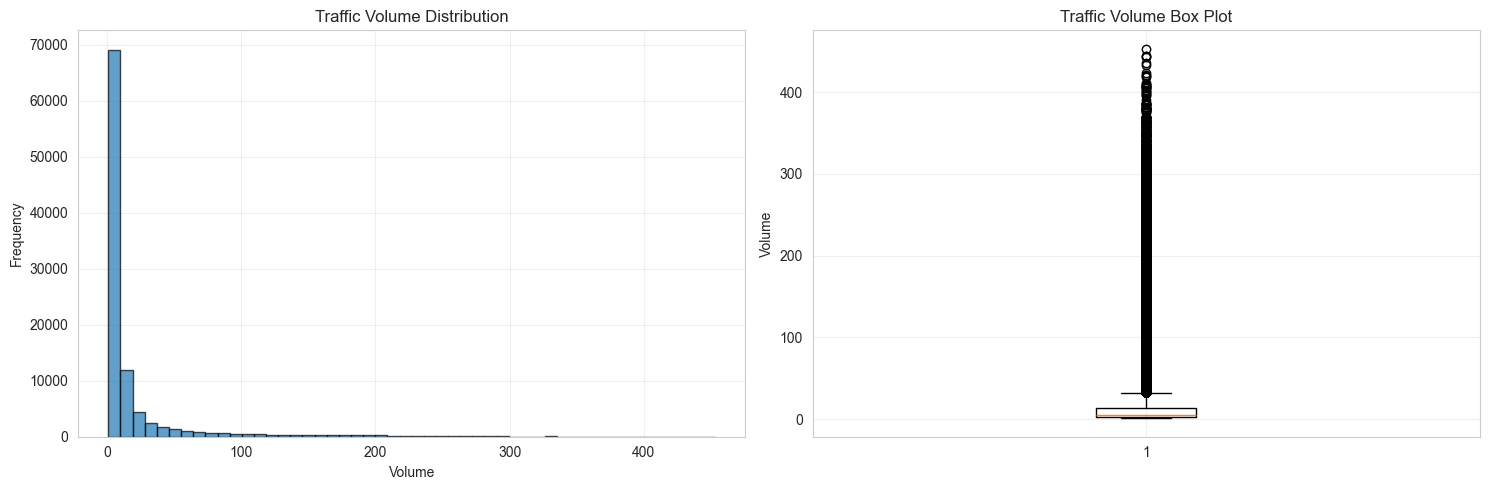

In [19]:
# Volume distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['volume'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Volume')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Traffic Volume Distribution')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['volume'])
axes[1].set_ylabel('Volume')
axes[1].set_title('Traffic Volume Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

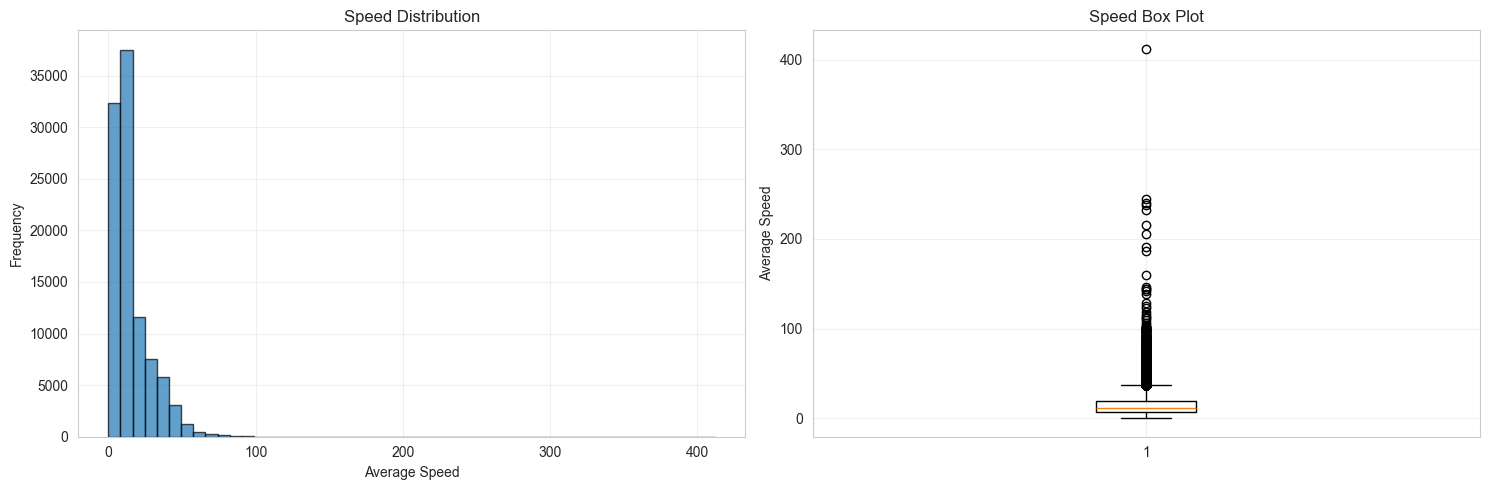

In [20]:
# Speed distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['speed_average'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Average Speed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Speed Distribution')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['speed_average'].dropna())
axes[1].set_ylabel('Average Speed')
axes[1].set_title('Speed Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

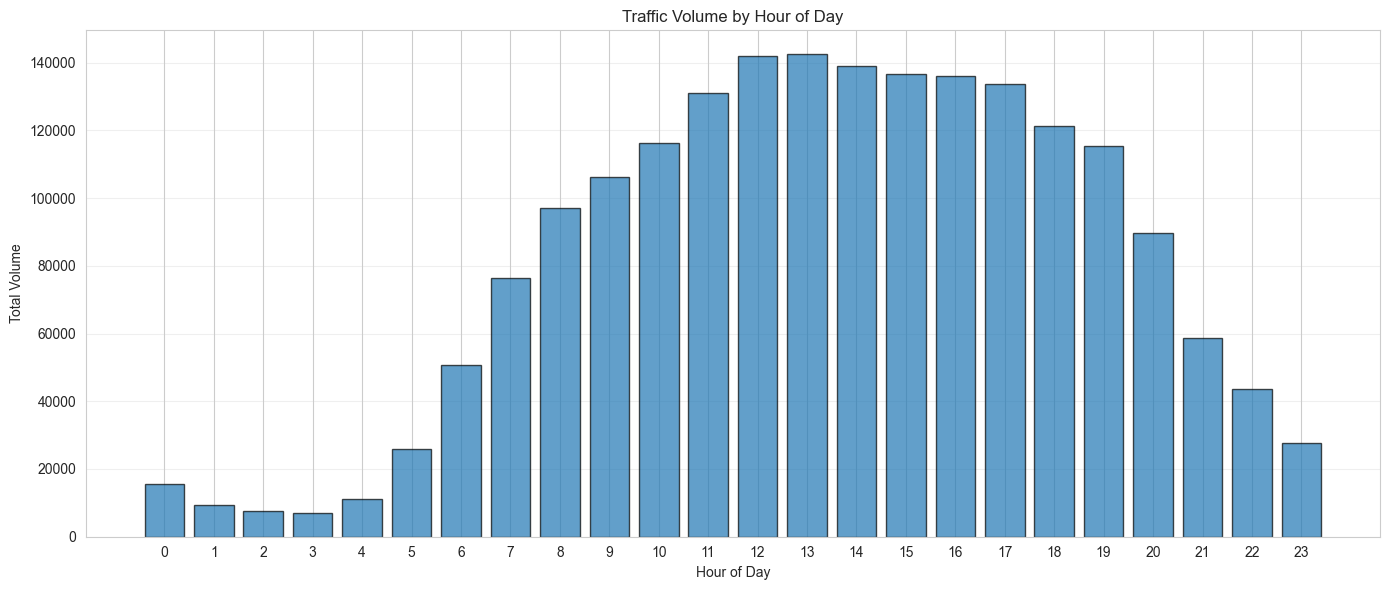

In [21]:
# Traffic by hour of day
hourly_volume = df.groupby('hour')['volume'].sum()

plt.figure(figsize=(14, 6))
plt.bar(hourly_volume.index, hourly_volume.values, edgecolor='black', alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Total Volume')
plt.title('Traffic Volume by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

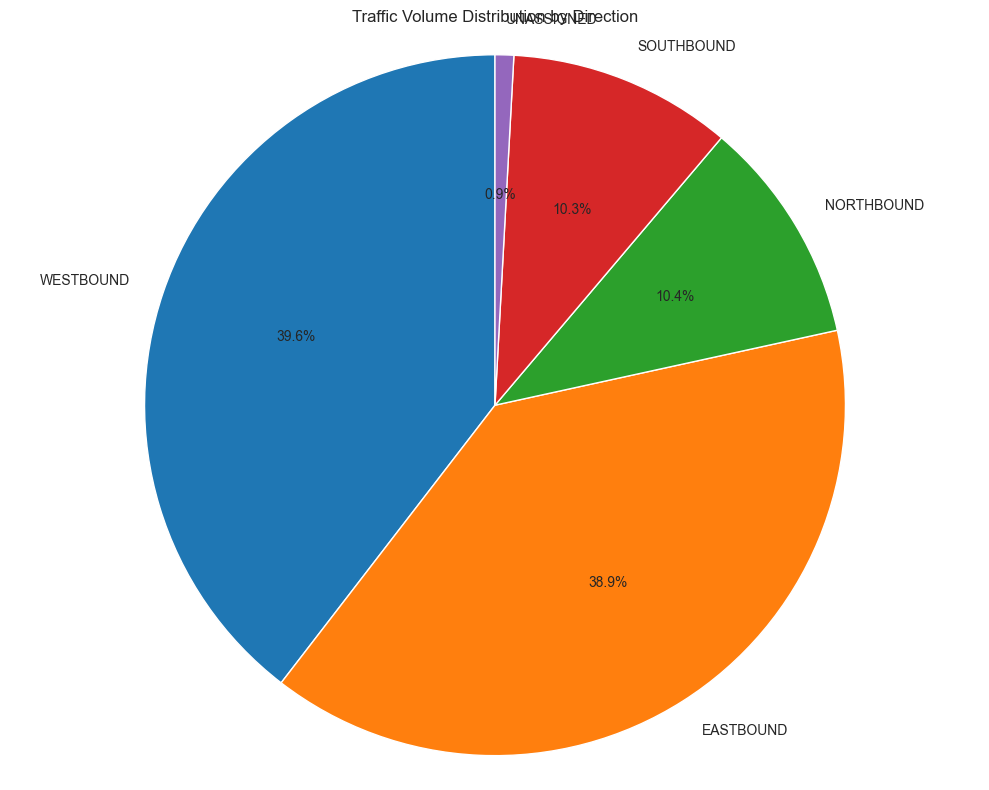

In [22]:
# Traffic by direction (pie chart)
direction_volume = df.groupby('direction')['volume'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.pie(direction_volume.values, labels=direction_volume.index, autopct='%1.1f%%', startangle=90)
plt.title('Traffic Volume Distribution by Direction')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 12. Summary Statistics Table

In [23]:
# Create comprehensive summary
summary = {
    'Metric': [
        'Total Records',
        'Total Volume',
        'Unique Intersections',
        'Unique Devices',
        'Date Range (days)',
        'Avg Volume per Record',
        'Avg Speed',
        'Heavy Vehicle %',
        'Missing Values',
        'Duplicate Records'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['volume'].sum():,.0f}",
        f"{df['intersection_name'].nunique():,}",
        f"{df['atd_device_id'].nunique():,}",
        f"{(df['read_date'].max() - df['read_date'].min()).days}",
        f"{df['volume'].mean():.2f}",
        f"{df['speed_average'].mean():.2f}",
        f"{(df['heavy_vehicle'].sum() / len(df) * 100):.2f}%",
        f"{df.isnull().sum().sum()}",
        f"{df.duplicated().sum()}"
    ]
}

summary_df = pd.DataFrame(summary)
print("\n" + "="*60)
print("TRAFFIC DATA SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


TRAFFIC DATA SUMMARY
               Metric     Value
        Total Records   100,000
         Total Volume 1,940,927
 Unique Intersections        11
       Unique Devices        11
    Date Range (days)         7
Avg Volume per Record     19.41
            Avg Speed     15.38
      Heavy Vehicle %    36.75%
       Missing Values         0
    Duplicate Records         0
